<a href="https://colab.research.google.com/github/NatShed/MO_Attack/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 4. Математика CNN и FGSM-атаки

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам Лекции 3**

**Формат:** индивидуально

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить математический аппарат свёртки и рецептивного поля, а также научиться конструировать и анализировать evasion-атаку методом Fast Gradient Sign Method (FGSM) на реальной свёрточной сети.

## Результаты обучения
После выполнения работы вы должны уметь:
- рассчитывать размер выходной карты признаков и рецептивное поле для произвольной конфигурации свёрточных слоёв;
- объяснять архитектурные решения LeNet, AlexNet, VGG, ResNet и их мотивацию;
- реализовывать FGSM-атаку по формуле $ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $;
- строить и интерпретировать зависимость Attack Success Rate от бюджета $\epsilon$;
- применять adversarial training как базовую меру защиты.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Часть I. Математика CNN

### 1.1. Расчёт размера feature map

**Задание:** реализуйте функцию расчёта размера выходной карты признаков по формуле

$ H_{out} = \left\lfloor \frac{H - k + 2p}{s} \right\rfloor + 1 $

и рассчитайте её для заданных конфигураций.

In [ ]:
# TODO: реализуйте функцию
def conv_output_size(H, k, s, p):
    """
    H — размер входа (например, 28).

k — размер ядра (3, 5, 7).

s — stride (шаг).

p — padding (сколько добавляем по краям нулей по краям, чтоб ядро могло дойти до краев).
    """
    return (H - k + 2 * p) // s + 1

# Рассчитайте H_out для следующих конфигураций и заполните таблицу результатов
configs = [
    {"H": 224, "k": 7, "s": 2, "p": 3},
    {"H": 224, "k": 3, "s": 1, "p": 1},
    {"H": 56,  "k": 3, "s": 2, "p": 1},
    {"H": 28,  "k": 5, "s": 1, "p": 0},
]
print(f"{'H':>5} | {'k':>3} | {'s':>3} | {'p':>3} | {'H_out':>6}")
print("=" * 35)
# TODO: примените conv_output_size ко всем конфигурациям и выведите результат
for c in configs:
    h_out = conv_output_size(c["H"], c["k"], c["s"], c["p"])
    print(f"{c['H']:>5} | {c['k']:>3} | {c['s']:>3} | {c['p']:>3} | {h_out:>6}")


    H |   k |   s |   p |  H_out
  224 |   7 |   2 |   3 |    112
  224 |   3 |   1 |   1 |    224
   56 |   3 |   2 |   1 |     28
   28 |   5 |   1 |   0 |     24


### 1.2. Рецептивное поле

**Задание:** реализуйте функцию расчёта рецептивного поля по рекуррентной формуле

$ RF_L = RF_{L-1} + (k_L - 1)\prod_{i=1}^{L-1} s_i $

и сравните рецептивное поле для двух архитектурных решений с одинаковым итоговым покрытием, но разным числом параметров (в духе аргумента VGG о малых ядрах).

In [ ]:
# TODO: реализуйте функцию
def receptive_field(layers):
    rf = 1                    # RF входа = 1 пиксель
    stride_product = 1        # произведение страйдов
    for k, s in layers:       # для каждого слоя (k, s)
        rf = rf + (k - 1) * stride_product
        stride_product *= s
    return rf

# Вариант А: три слоя 3x3 (stride=1)
layers_a = [(3, 1), (3, 1), (3, 1)]
# Вариант Б: один слой 7x7 (stride=1)
layers_b = [(7, 1)]

# TODO: рассчитайте RF для обоих вариантов и сравните
rf_a = receptive_field(layers_a)
rf_b = receptive_field(layers_b)

print(f"Вариант А (3×3 × 3): RF = {rf_a}")
print(f"Вариант Б (7×7 × 1): RF = {rf_b}")
print(f"Одинаковое RF? {rf_a == rf_b}")

Вариант А (3×3 × 3): RF = 7
Вариант Б (7×7 × 1): RF = 7
Одинаковое RF? True


In [ ]:
# TODO: рассчитайте и сравните число обучаемых параметров для вариантов А и Б
# при числе входных/выходных каналов C = 64 (без учёта bias)
# Формула для k x k свёртки с C входными и C выходными каналами: k^2 * C^2

C = 64
# TODO

# Вариант А: три свёртки 3x3
# Каждая: 3^2 * C * C = 9C^2 параметров
params_a = 3 * (3**2 * C**2)

# Вариант Б: одна свёртка 7x7
# 7^2 * C * C = 49C^2 параметров
params_b = 7**2 * C**2

print(f"Параметры А (3×3 × 3): {params_a:,}")
print(f"Параметры Б (7×7 × 1): {params_b:,}")
print(f"Вариант Б требует в {params_b / params_a:.3f} раз больше параметров, чем вариант А")
print(f"Экономия А относительно Б: {(1 - params_a/params_b) * 100:.1f}%")

Параметры А (3×3 × 3): 110,592
Параметры Б (7×7 × 1): 200,704
Вариант Б требует в 1.815 раз больше параметров, чем вариант А
Экономия А относительно Б: 44.9%


**Вопрос для отчёта:** при одинаковом рецептивном поле какой вариант (А или Б) эффективнее по числу параметров и почему? Как это соотносится с архитектурным принципом VGG?

При одинаковом рецептивном поле (RF = 7) вариант А (три слоя 3×3) эффективнее по числу параметров: 27C² (27 весов на канал)против 49C², то есть экономия ~45%. Как мы видим, количество параметров свёрточного слоя растёт квадратично от размера ядра (k^2). Т.е. много малых ядер дешевле одного большого при том же рецептивном поле.

Это напрямую соотностися с архитектурным принципом VGG - использовать маленькие ядра и наращивать глубину через повторение однородных блоков.
При такой конфигурации сети нужно меньше параметров, значит, риск переобучение меньше, при этом рецепптивное поле то же, она способна выучивать более сложные признаки засчет большего количества нелинейности (3 функции активации на 3 слоях против одной), и, как следствие, у такой сети лучше сходимость.


### 1.3. Собственная свёрточная архитектура

**Задание:** спроектируйте небольшую CNN для классификации MNIST (2–3 свёрточных слоя + пулинг + полносвязный классификатор). Рассчитайте вручную (в markdown-ячейке) итоговое рецептивное поле последнего свёрточного слоя перед тем, как реализовывать сеть в коде.

Формула рецептивного поля: $ RF_L = RF_{L-1} + (k_L - 1)\prod_{i=1}^{L-1} s_i $

RF0 = 1

Сверточный слой 1: ядро - 3, страйд -1

RF1 = 1 + (3 - 1) * 1 = 3

Пуллинг1 (2х2, s2 = 2):

RF2 = 3 + (2 - 1) * 1 = 4
Пояляется свертка: 14х14
Сверточный слой 2: ядро - 3, страйд - 1

RF3 = 4 + (3 - 1)* 1 * 2 = 8

Пуллинг2 (2х2, s2 = 2):  

RF4 =8 + (2 - 1)* 1 * 2 * 1  = 10

Свертка: 7х7
Сверточный слой 3: ядро - 3, страйд - 1

RF5 = 10 + (3 - 1)* 1 * 2 * 1 * 2 = 18

Это означает, что каждый нейрон в Conv3 «видит» область 18×18 на исходном изображении 28×28 — примерно 41% площади. Этого достаточно для распознавания целых цифр (петли «8», изгибы «3»)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv1: 1 -> 32, 3x3, padding=1 (сохраняет 28x28)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)   # 28 -> 14

        # Conv2: 32 -> 64, 3x3, padding=1 (сохраняет 14x14)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)   # 14 -> 7

        # Классификатор
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Блок 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        # Блок 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        # Разворачиваем в вектор
        x = x.view(x.size(0), -1)      # [B, 64*7*7] = [B, 3136]

        # Классификатор
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## Часть II. Данные и обучение базовой модели

In [ ]:
# TODO: загрузите MNIST через torchvision.datasets
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 57.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.66MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.08MB/s]

Train: 60000, Test: 10000


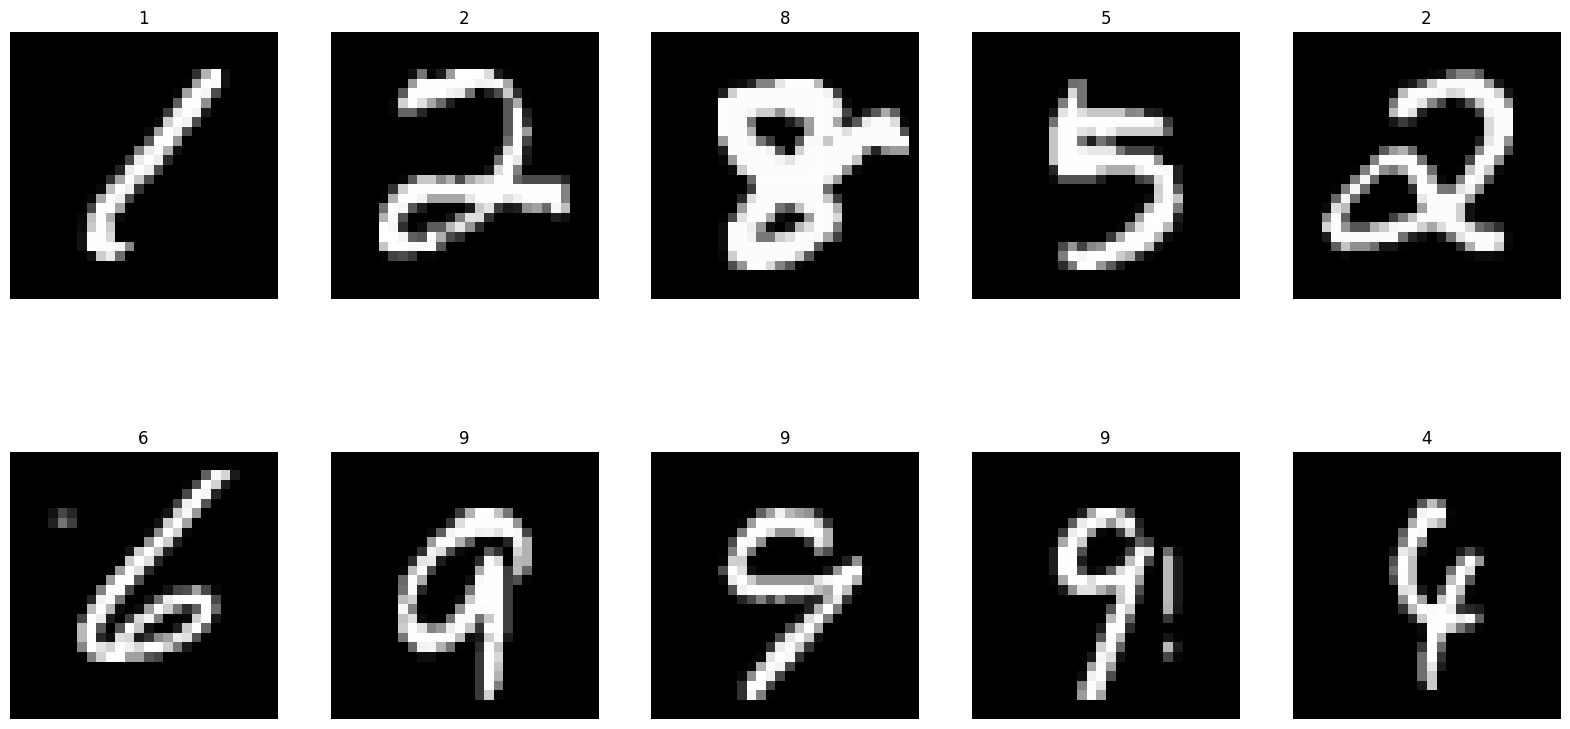

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
for ax, img, lbl in zip(axes.flat, images[:10], labels[:10]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(classes[lbl] if 'classes' in dir() else lbl.item())
    ax.axis('off')
plt.show()

In [ ]:
# TODO: обучите вашу модель MyCNN на train_loader (2-3 эпохи достаточно)
# Используйте CrossEntropyLoss и Adam

model = MyCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# TODO: цикл обучения
EPOCHS = 3
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/total:.4f} | Train Acc: {correct/total:.4f}")


Epoch 1/3 | Loss: 0.2515 | Train Acc: 0.9230
Epoch 2/3 | Loss: 0.1177 | Train Acc: 0.9648
Epoch 3/3 | Loss: 0.0951 | Train Acc: 0.9713


In [ ]:
# TODO: оцените точность на тестовой выборке (clean accuracy)
# Сохраните значение в переменную clean_accuracy для дальнейшего использования

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

clean_accuracy = correct / total
print(f"Clean accuracy: {clean_accuracy:.4f}")


Clean accuracy: 0.9859


## Часть III. FGSM-атака

### 3.1. Реализация FGSM

**Задание:** реализуйте функцию FGSM-атаки по формуле

$ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $

Функция должна принимать модель, батч изображений и меток, значение $\epsilon$ и возвращать adversarial-примеры.

In [ ]:
# TODO: реализуйте функцию FGSM-атаки
def fgsm_attack(model, x, y, epsilon, criterion):
    """
    Fast Gradient Sign Method.

    x_adv = x + ε · sign(∇_x J(θ, x, y))

    Аргументы:
        model: обученная нейросеть
        x: батч изображений [B, C, H, W]
        y: батч меток [B]
        epsilon: бюджет возмущения (L∞-норма)
        criterion: функция потерь (например, nn.CrossEntropyLoss())

    Возвращает:
        x_adv: adversarial-примеры той же формы, что и x
    """
    # 1. Копируем вход и включаем отслеживание градиента
    x_adv = x.clone().detach().requires_grad_(True)

    # 2. Прямой проход через модель
    logits = model(x_adv)

    # 3. Вычисляем loss
    loss = criterion(logits, y)

    # 4. Обратный проход — считаем градиент loss по входу x_adv
    model.zero_grad()
    loss.backward()

    # 5. Строим возмущение: ε * sign(градиент)
    perturbation = epsilon * x_adv.grad.sign()

    # 6. Добавляем возмущение и обрезаем в [0, 1]
    x_adv = x + perturbation
    x_adv = torch.clamp(x_adv, 0.0, 1.0)

    return x_adv.detach()


### 3.2. Визуализация атаки на одном примере

**Задание:** выберите один тестовый пример, постройте для него adversarial-версию при $\epsilon = 0.2$ и визуализируйте три изображения: оригинал, возмущение, adversarial-пример — с указанием предсказаний модели и уверенности (confidence) для каждого.

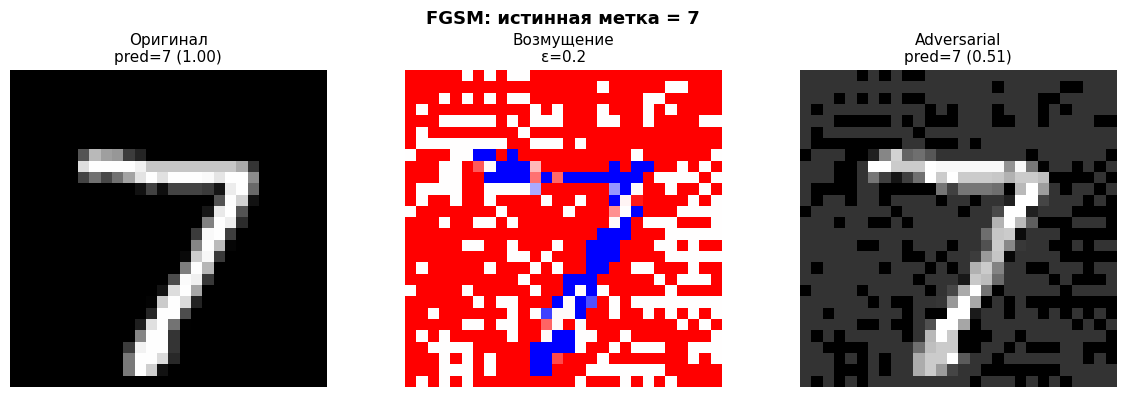

In [ ]:
# TODO: выберите пример из test_loader
# TODO: примените fgsm_attack
# TODO: получите предсказания модели на оригинале и adversarial-примере (класс + confidence через softmax)
# TODO: постройте matplotlib-визуализацию из 3 подграфиков
# Берём один пример
images, labels = next(iter(test_loader))
img = images[0:1].to(device)
label = labels[0:1].to(device)

# Атака при ε = 0.2
eps_vis = 0.2
img_adv = fgsm_attack(model, img, label, eps_vis, criterion)

# Предсказания
model.eval()
with torch.no_grad():
    logits_clean = model(img)
    logits_adv = model(img_adv)
    pred_clean = logits_clean.argmax(dim=1).item()
    pred_adv = logits_adv.argmax(dim=1).item()
    conf_clean = torch.softmax(logits_clean, dim=1)[0, pred_clean].item()
    conf_adv = torch.softmax(logits_adv, dim=1)[0, pred_adv].item()

# Возмущение
perturbation = (img_adv - img).cpu().squeeze().numpy()

# Денормализация не нужна — пиксели уже в [0, 1]
img_np = img.cpu().squeeze().numpy()
img_adv_np = img_adv.cpu().squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f"Оригинал\npred={pred_clean} ({conf_clean:.2f})", fontsize=11)
axes[0].axis('off')

axes[1].imshow(perturbation, cmap='bwr', vmin=-eps_vis, vmax=eps_vis)
axes[1].set_title(f"Возмущение\nε={eps_vis}", fontsize=11)
axes[1].axis('off')

axes[2].imshow(img_adv_np, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f"Adversarial\npred={pred_adv} ({conf_adv:.2f})", fontsize=11)
axes[2].axis('off')

plt.suptitle(f"FGSM: истинная метка = {label.item()}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Найден adversarial-пример:
  Истинная метка:       9
  Clean предсказание:   9  (conf = 0.9965)
  Adv предсказание:     4   (conf = 0.7047)


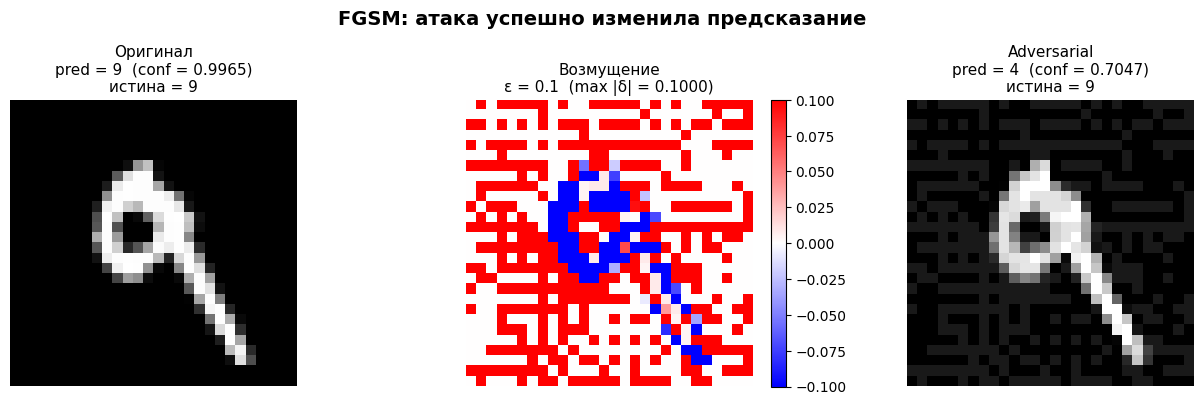

In [ ]:
def find_first_adversarial(model, loader, epsilon, criterion, device, max_examples=1000):
    """
    Идёт по тестовым примерам, пока не найдёт первый, где FGSM меняет предсказание.
    Возвращает: (image, label, adv_image, clean_pred, adv_pred, clean_conf, adv_conf)
    """
    model.eval()
    seen = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Оставляем только правильно классифицированные
        with torch.no_grad():
            logits_clean = model(images)
            clean_preds = logits_clean.argmax(dim=1)
            clean_probs = torch.softmax(logits_clean, dim=1)
        mask = clean_preds == labels
        images = images[mask]
        labels = labels[mask]
        clean_preds = clean_preds[mask]
        clean_probs = clean_probs[mask]

        if len(images) == 0:
            continue

        # Атакуем весь батч
        x_adv = fgsm_attack(model, images, labels, epsilon, criterion)

        with torch.no_grad():
            logits_adv = model(x_adv)
            adv_preds = logits_adv.argmax(dim=1)
            adv_probs = torch.softmax(logits_adv, dim=1)

        # Ищем первый пример, где предсказание изменилось
        changed = adv_preds != labels
        if changed.any():
            idx = changed.nonzero(as_tuple=True)[0][0].item()

            clean_conf = clean_probs[idx, clean_preds[idx]].item()
            adv_conf   = adv_probs[idx, adv_preds[idx]].item()

            print(f"Найден adversarial-пример:")
            print(f"  Истинная метка:       {labels[idx].item()}")
            print(f"  Clean предсказание:   {clean_preds[idx].item()}  (conf = {clean_conf:.4f})")
            print(f"  Adv предсказание:     {adv_preds[idx].item()}   (conf = {adv_conf:.4f})")

            return (images[idx].cpu(), labels[idx].cpu(), x_adv[idx].cpu(),
                    clean_preds[idx].item(), adv_preds[idx].item(),
                    clean_conf, adv_conf)

        seen += len(images)
        if seen >= max_examples:
            break

    print("Не найдено adversarial-примеров в заданном бюджете примеров.")
    return None
result = find_first_adversarial(model, test_loader, epsilon=0.1,
                                 criterion=criterion, device=device)

if result is not None:
    img, label, img_adv, pred_clean, pred_adv, conf_clean, conf_adv = result

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    # --- 1. Оригинал ---
    axes[0].imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(
        f"Оригинал\n"
        f"pred = {pred_clean}  (conf = {conf_clean:.4f})\n"
        f"истина = {label.item()}",
        fontsize=11
    )
    axes[0].axis('off')

    # --- 2. Возмущение ---
    noise = (img_adv - img).squeeze().numpy()
    im = axes[1].imshow(noise, cmap='bwr', vmin=-0.1, vmax=0.1)
    axes[1].set_title(f"Возмущение\nε = 0.1  (max |δ| = {np.abs(noise).max():.4f})",
                      fontsize=11)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # --- 3. Adversarial ---
    axes[2].imshow(img_adv.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(
        f"Adversarial\n"
        f"pred = {pred_adv}  (conf = {conf_adv:.4f})\n"
        f"истина = {label.item()}",
        fontsize=11
    )
    axes[2].axis('off')

    plt.suptitle("FGSM: атака успешно изменила предсказание",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


**Вопрос для отчёта:** удалось ли изменить предсказание модели? Является ли визуально заметным возмущение? Какой класс присвоила модель adversarial-примеру?

Не сразу удалось провести атаку, на первом выбранном примере, в котором модель была уверена с confidence 1.000, что это 7, при ε = 0.2 предсказание осталось 7, но уверенность упала до 0.51.

Поэтому дополнительно нашла первый пример из выборки, в котором атака все-таки удалась и предсказание изменилось: изначально была 9 с уверенность 0,99, после атаки предсказание модели - 4, модель уверена на 0,7. Т.е. модель не просто ошиблась, а она еще и уверена в своейй ошибке.

FGSM добавляет шум с амплитудой ε (обычно 0.1–0.2), что соответствует изменению яркости пикселей на 10–20% от диапазона [0,1]. Визуально для нас это заметно, выглядит как шум, фон стал серый, но это не мешает узнать исходную цифру.

### 3.3. Attack Success Rate в зависимости от ε

**Задание:** постройте график зависимости Attack Success Rate (доли тестовых примеров, на которых атака меняет предсказание) от бюджета \(\epsilon\) для набора значений \(\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}\).

ε =  0.00  →  ASR = 0.0000
ε =  0.02  →  ASR = 0.0143
ε =  0.05  →  ASR = 0.0571
ε =  0.10  →  ASR = 0.2095
ε =  0.15  →  ASR = 0.4587
ε =  0.20  →  ASR = 0.7032
ε =  0.30  →  ASR = 0.9222


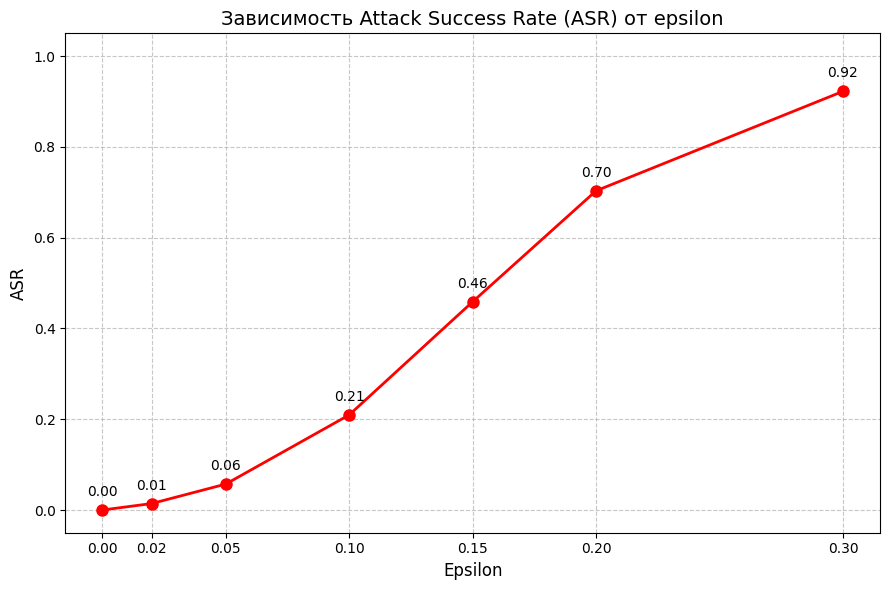

In [ ]:
# TODO: реализуйте функцию оценки ASR на подмножестве тестовой выборки
def evaluate_asr(model, loader, epsilon, criterion, n_batches=10):
    """
    Считает Attack Success Rate на подмножестве тестовой выборки.

    Успех атаки = модель правильно классифицировала оригинал,
                  но ошиблась на adversarial-примере.

    Аргументы:
        model: обученная модель
        loader: DataLoader тестовой выборки
        epsilon: бюджет L∞-возмущения
        criterion: функция потерь
        n_batches: сколько батчей использовать (для скорости)

    Возвращает:
        asr (float): доля успешных атак среди правильно классифицированных
    """
    model.eval()
    success = 0
    total = 0

    for i, (images, labels) in enumerate(loader):
        if i >= n_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        # --- 1. Оставляем только правильно классифицированные примеры ---
        with torch.no_grad():
            clean_preds = model(images).argmax(dim=1)
        mask = clean_preds == labels
        images = images[mask]
        labels = labels[mask]

        if len(images) == 0:
            continue

        # --- 2. При ε=0 атаки нет — все предсказания сохраняются ---
        if epsilon == 0.0:
            adv_preds = clean_preds[mask]
        else:
            x_adv = fgsm_attack(model, images, labels, epsilon, criterion)
            with torch.no_grad():
                adv_preds = model(x_adv).argmax(dim=1)

        # --- 3. Считаем успешные атаки ---
        success += (adv_preds != labels).sum().item()
        total += labels.size(0)

    return success / total if total > 0 else 0.0

epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
# TODO: рассчитайте ASR для каждого epsilon и постройте график


asr_values = []
for eps in epsilons:
    asr = evaluate_asr(model, test_loader, eps, criterion, n_batches=10)
    asr_values.append(asr)
    print(f"ε = {eps:>5.2f}  →  ASR = {asr:.4f}")

# Построение графика
plt.figure(figsize=(9, 6))
plt.plot(epsilons, asr_values, marker='o', linestyle='-', color='red', linewidth=2, markersize=8)
plt.title('Зависимость Attack Success Rate (ASR) от epsilon', fontsize=14)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('ASR', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(epsilons)
plt.ylim(-0.05, 1.05)

for i, txt in enumerate(asr_values):
    plt.annotate(f"{txt:.2f}", (epsilons[i], asr_values[i]),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** при каком значении $\epsilon$ ASR начинает быстро расти? Совместимо ли это значение с визуальной незаметностью возмущения (сравните с примером из п.3.2)?

ASR начинает быстро расти при epsilon 0.1-0.15. зона ε ∈ [0.10, 0.20] - особенно сильный рост.

Это значение совместимо с визуальностью возмущения из предыдущего пункта - при значениях epsilon выше 0.1 возмущения достаточно хорошо видны для человека, но цифра легко узнается, а вот для модели это совсем критично и успешность атаки сильно возрастает.


## Часть IV. Adversarial training

**Задание:** обучите вторую модель (такую же архитектуру, как MyCNN) с использованием adversarial training по формуле

$ \tilde{J}(\theta, x, y) = \alpha J(\theta, x, y) + (1-\alpha) J(\theta, x_{adv}, y) $

с $\alpha = 0.5$ и $\epsilon$, использованным при обучении, равным одному из средних значений из п.3.3.

In [ ]:
# TODO: реализуйте цикл adversarial training
# На каждом шаге:
# 1. Постройте x_adv через fgsm_attack для текущего батча
# 2. Посчитайте комбинированный loss (alpha * loss_clean + (1-alpha) * loss_adv)
# 3. Сделайте шаг оптимизации
# Та же архитектура MyCNN, но с нуля
adv_model = MyCNN().to(device)
optimizer_adv = optim.Adam(adv_model.parameters(), lr=0.001)
criterion_adv = nn.CrossEntropyLoss()

# Параметры adversarial training
ALPHA = 0.5        # вес чистых потерь
EPS_TRAIN = 0.15    # бюджет атаки при обучении
EPOCHS_ADV = 3

for epoch in range(EPOCHS_ADV):
    adv_model.train()

    running_loss = 0.0
    correct_clean = 0
    correct_adv   = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_adv.zero_grad()

        # --- 1. Loss на ЧИСТЫХ данных ---
        logits_clean = adv_model(images)
        loss_clean = criterion_adv(logits_clean, labels)

        # --- 2. Adversarial-пример «на лету» ---
        x_adv = fgsm_attack(adv_model, images, labels, EPS_TRAIN, criterion_adv)

        # --- 3. Loss на ADVERSARIAL данных ---
        logits_adv = adv_model(x_adv)
        loss_adv = criterion_adv(logits_adv, labels)

        # --- 4. Комбинированный loss ---
        loss = ALPHA * loss_clean + (1 - ALPHA) * loss_adv

        # --- 5. Backprop и шаг ---
        loss.backward()
        optimizer_adv.step()

        # --- Метрики ---
        running_loss  += loss.item() * images.size(0)
        correct_clean += (logits_clean.argmax(dim=1) == labels).sum().item()
        correct_adv   += (logits_adv.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}/{EPOCHS_ADV} | "
          f"Loss: {running_loss/total:.4f} | "
          f"Clean Acc: {correct_clean/total:.4f} | "
          f"Adv Acc: {correct_adv/total:.4f}")


Epoch 1/3 | Loss: 0.3650 | Clean Acc: 0.9445 | Adv Acc: 0.8288
Epoch 2/3 | Loss: 0.1949 | Clean Acc: 0.9759 | Adv Acc: 0.9045
Epoch 3/3 | Loss: 0.1556 | Clean Acc: 0.9808 | Adv Acc: 0.9213


Adversarial-trained clean accuracy: 0.9875
Обычная модель clean accuracy:      0.9859
Падение clean accuracy:             -0.0016


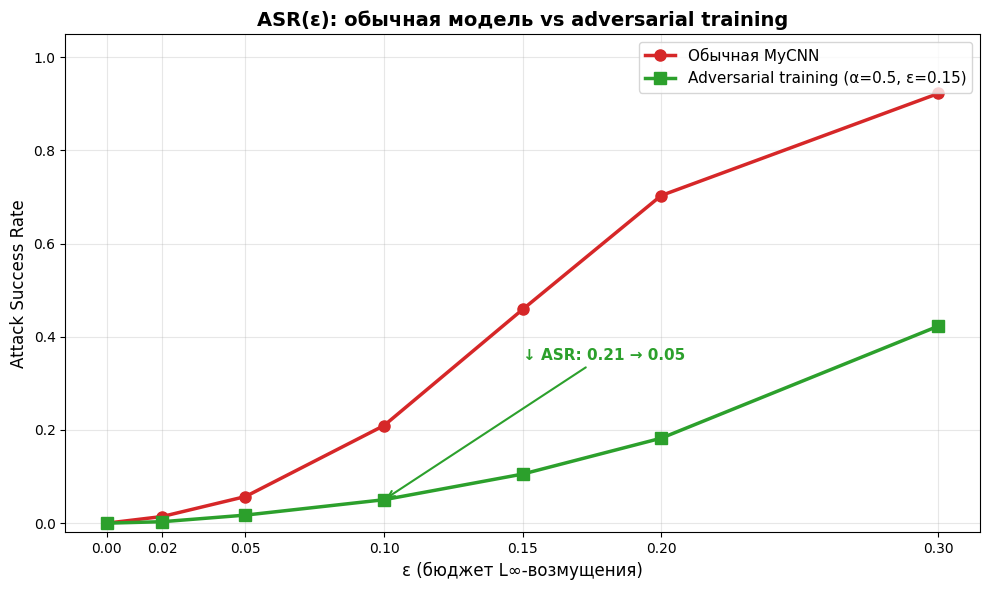

In [ ]:
# TODO: оцените clean accuracy adversarial-trained модели
adv_model.eval()

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = adv_model(images)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

adv_clean_accuracy = correct / total

print(f"Adversarial-trained clean accuracy: {adv_clean_accuracy:.4f}")
print(f"Обычная модель clean accuracy:      {clean_accuracy:.4f}")
print(f"Падение clean accuracy:             {clean_accuracy - adv_clean_accuracy:.4f}")
# TODO: постройте график ASR(epsilon) для adv_model и сравните с обычной моделью на одном графике
import matplotlib.pyplot as plt

# Считаем ASR для adversarial-trained модели
asr_adv_model = [evaluate_asr(adv_model, test_loader, eps, criterion)
                 for eps in epsilons]

# Строим график
# Строим график
plt.figure(figsize=(10, 6))

plt.plot(epsilons, asr_values, marker='o', markersize=8, lw=2.5,
         label="Обычная MyCNN", color='#d62728')
plt.plot(epsilons, asr_adv_model, marker='s', markersize=8, lw=2.5,
         label=f"Adversarial training (α=0.5, ε={EPS_TRAIN})",
         color='#2ca02c')

plt.title("ASR(ε): обычная модель vs adversarial training",
          fontweight='bold', fontsize=14)
plt.xlabel("ε (бюджет L∞-возмущения)", fontsize=12)
plt.ylabel("Attack Success Rate", fontsize=12)
plt.xticks(epsilons)
plt.ylim(-0.02, 1.05)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)

# Аннотация — вертикальный разрыв при ε = 0.1
i = epsilons.index(0.1)
plt.annotate(
    f"↓ ASR: {asr_values[i]:.2f} → {asr_adv_model[i]:.2f}",
    xy=(0.1, asr_adv_model[i]),
    xytext=(0.15, 0.35),
    fontsize=11, color='#2ca02c', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.5)
)

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** насколько снизился Attack Success Rate после adversarial training при том же \(\epsilon\)? Изменилась ли clean accuracy (точность на чистых данных)? Согласуется ли это с ограничением FGSM-adversarial training, упомянутым в лекции (устойчивость только к одношаговым атакам)?

При зона ε ∈ [0.10, 0.15] успех атак упал в 3 раза, устойчивость модели в принципе возрасла при любом ε > 0.05.

При этом  clean_accuracy практически не изменилась, т.е. на простом нашем датасети адверсариал примеры не ухудшили ее.

Одношаговая FGSM-атака — это метод adversarial-атаки, который делает ровно один шаг в направлении знака градиента функции потерь по входу:
Каждый пиксель сдвигается на ±ε — в сторону роста Loss.

Даже маленькое ε на каждом из 784 пикселей суммируется в большой сдвиг логитов.

Наш эксперимент подтвердил лекцию, что тренировка на возмущенных данных помогает против FGSM-атаки.

## Часть V. Итоговый вывод

**Вопрос для отчёта:** сформулируйте связь между математическими свойствами CNN (высокая размерность входа, локальная связность) и существованием adversarial-примеров, опираясь на линейную гипотезу Гудфеллоу. Почему увеличение разрешения изображения потенциально увеличивает уязвимость модели к $L_\infty$-ограниченным атакам?

Линейные сети в пространстве высокой размерности ведут себя преимущественно линейно.
Высока яразмерность увеличивает возможности у атаки, так как даже маленький ε, при суммировании вкладов, дает очень большой сдвиг.

Локальная связность — это принцип, при котором каждый нейрон связан только с локальной областью входа, а не со всеми входами. Локальная связность учитывает, что соседние пиксели связаны. Это хорошое архитектурно решение - уменьшает число параметров, но не уменьшает уязвимость. Ядро — это линейная комбинация 9 пикселей. Градиент по входу считается через ту же линейную операцию.

Возмущение добавляется во все пиксели. FGSM меняет каждый пиксель на ε. Каждое локальное окно получает свою порцию возмущения

$L_\infty$-ограничение означает, что каждый пиксель можно изменить не более чем на epsilon. При увелечении изображения у злоумышленника появляется большее количество параметров, которые можно изменить на небольшую величину. То есть тут та же проблема высокой размерности. При расширении при том же сдвиге суммарный эффект сильнее, а  атака дешевле. Чем больше таких входных измененных параметров, тем больше итоговое отклонение логита, следовательно, выше вероятность неверного предсказания

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже .

### С1. Влияние глубины архитектуры на устойчивость к FGSM
Обучите две версии MyCNN с разной глубиной (например, 2 и 5 свёрточных слоёв, при сопоставимом числе параметров) и сравните их ASR(ε). Свяжите результат с обсуждением иерархии признаков и рецептивного поля из лекции.

### С2. Целевая (targeted) FGSM-атака
Модифицируйте FGSM так, чтобы атака заставляла модель предсказывать конкретный целевой класс (а не просто любой неверный), минимизируя loss по целевому классу вместо максимизации loss по истинному. Сравните Success Rate целевой и нецелевой атаки при одинаковом ε.

### С3. Трансферируемость adversarial-примеров
Обучите две модели с разной архитектурой (например, разное число слоёв/каналов). Постройте adversarial-примеры для модели А методом FGSM и проверьте, насколько успешно они обманывают необученную на этих примерах модель Б. Свяжите результат со свойством трансферируемости, разобранным в лекции (Szegedy et al.).

### С4. Аналитическая иллюстрация линейной гипотезы
Реализуйте эксперимент из демонстрационного ноутбука (раздел «линейная гипотеза») самостоятельно: постройте график зависимости среднего сдвига выхода линейной модели \( w^T\eta^* = \epsilon\|w\|_1 \) от размерности входа \(n\) для нескольких значений \(\epsilon\) на одном графике. Объясните, почему это объясняет уязвимость моделей компьютерного зрения именно с ростом разрешения изображений.


In [ ]:
# С1 - ВЛИЯНИЕ ГЛУБИНЫ АРХИТЕКТУРЫ
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt


class ShallowCNN(nn.Module):
    """Мелкая CNN: 2 свёрточных слоя."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

        # Global Average Pooling — сам приводит любой размер к 1×1
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)         # 28 → 14

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)         # 14 → 7

        x = self.gap(x)                # [B, 128, 1, 1]
        x = x.view(x.size(0), -1)      # [B, 128]
        return self.fc(x)


class DeepCNN(nn.Module):
    """Глубокая CNN: 5 свёрточных слоёв с меньшим числом каналов."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)

        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)         # 28 → 14

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.max_pool2d(x, 2)         # 14 → 7

        x = F.relu(self.bn5(self.conv5(x)))
        # третий пулинг УБРАН — оставляем 7×7, чтобы RF был больше

        x = self.gap(x)                # [B, 128, 1, 1]
        x = x.view(x.size(0), -1)      # [B, 128]
        return self.fc(x)


# --- Проверка размерностей ---
dummy = torch.randn(2, 1, 28, 28).to(device)
shallow_test = ShallowCNN().to(device)
deep_test = DeepCNN().to(device)

print(f"Shallow output: {shallow_test(dummy).shape}")
print(f"Deep output:    {deep_test(dummy).shape}")

# --- Считаем параметры ---
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nПараметры ShallowCNN: {count_params(shallow_test):,}")
print(f"Параметры DeepCNN:    {count_params(deep_test):,}")

Shallow output: torch.Size([2, 10])
Deep output:    torch.Size([2, 10])

Параметры ShallowCNN: 76,170
Параметры DeepCNN:    140,778


In [ ]:
def train_model(model, train_loader, epochs=3, lr=0.001):
    """Универсальная функция обучения."""
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/total:.4f} | "
              f"Train Acc: {correct/total:.4f}")

    return model

In [ ]:
print("=" * 60)
print("Обучение ShallowCNN (2 свёрточных слоя)")
print("=" * 60)
shallow = train_model(ShallowCNN(), train_loader, epochs=3)

print("\n" + "=" * 60)
print("Обучение DeepCNN (5 свёрточных слоёв)")
print("=" * 60)
deep = train_model(DeepCNN(), train_loader, epochs=3)

Обучение ShallowCNN (2 свёрточных слоя)
Epoch 1/3 | Loss: 0.8516 | Train Acc: 0.8038
Epoch 2/3 | Loss: 0.2988 | Train Acc: 0.9339
Epoch 3/3 | Loss: 0.1996 | Train Acc: 0.9528

Обучение DeepCNN (5 свёрточных слоёв)
Epoch 1/3 | Loss: 0.1734 | Train Acc: 0.9659
Epoch 2/3 | Loss: 0.0397 | Train Acc: 0.9883
Epoch 3/3 | Loss: 0.0294 | Train Acc: 0.9912


In [ ]:
def evaluate_clean(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return correct / total


acc_shallow = evaluate_clean(shallow, test_loader)
acc_deep    = evaluate_clean(deep, test_loader)

print(f"ShallowCNN clean accuracy: {acc_shallow:.4f}")
print(f"DeepCNN clean accuracy:    {acc_deep:.4f}")

ShallowCNN clean accuracy: 0.9441
DeepCNN clean accuracy:    0.9891


In [ ]:
epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]

# ASR для ShallowCNN
asr_shallow = [evaluate_asr(shallow, test_loader, eps, criterion, n_batches=10)
               for eps in epsilons]

# ASR для DeepCNN
asr_deep = [evaluate_asr(deep, test_loader, eps, criterion, n_batches=10)
            for eps in epsilons]

# Таблица
print(f"\n{'ε':>6} {'Shallow':>10} {'Deep':>10} {'Разница':>10}")
print("-" * 40)
for eps, a_s, a_d in zip(epsilons, asr_shallow, asr_deep):
    print(f"{eps:>6.2f} {a_s:>10.4f} {a_d:>10.4f} {a_d - a_s:>+10.4f}")


     ε    Shallow       Deep    Разница
----------------------------------------
  0.00     0.0000     0.0000    +0.0000
  0.02     0.2508     0.0206    -0.2302
  0.05     0.7326     0.3819    -0.3506
  0.10     0.9252     0.7385    -0.1867
  0.15     0.9635     0.8384    -0.1251
  0.20     0.9784     0.8796    -0.0988
  0.30     0.9817     0.9128    -0.0689


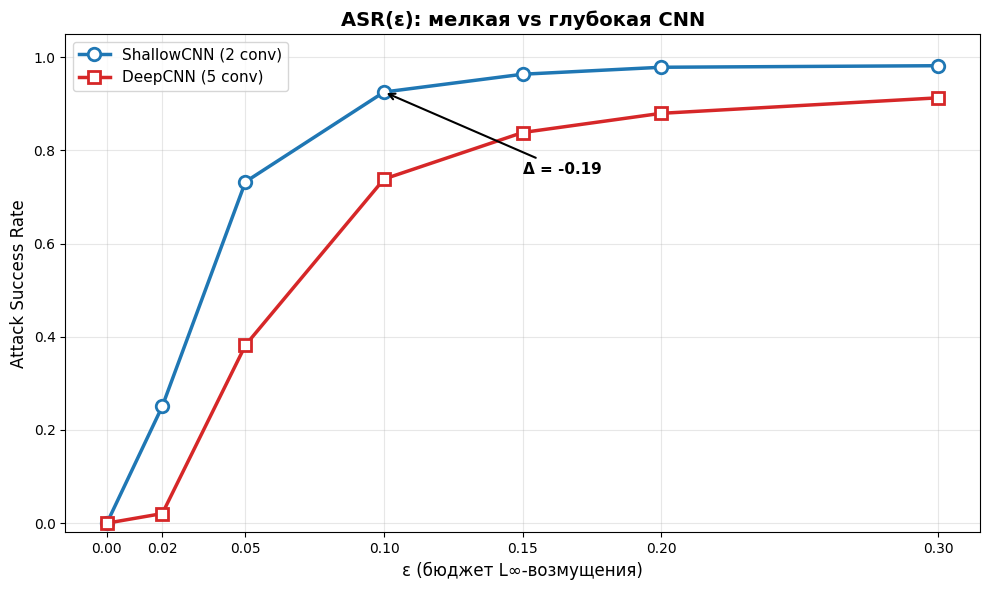

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(epsilons, asr_shallow, marker='o', markersize=9, lw=2.5,
         label="ShallowCNN (2 conv)", color='#1f77b4',
         markerfacecolor='white', markeredgewidth=2)

plt.plot(epsilons, asr_deep, marker='s', markersize=9, lw=2.5,
         label="DeepCNN (5 conv)", color='#d62728',
         markerfacecolor='white', markeredgewidth=2)

plt.title("ASR(ε): мелкая vs глубокая CNN",
          fontweight='bold', fontsize=14)
plt.xlabel("ε (бюджет L∞-возмущения)", fontsize=12)
plt.ylabel("Attack Success Rate", fontsize=12)
plt.xticks(epsilons)
plt.ylim(-0.02, 1.05)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)

# Аннотация — при ε=0.1
i = epsilons.index(0.1)
plt.annotate(
    f"Δ = {asr_deep[i] - asr_shallow[i]:+.2f}",
    xy=(0.1, max(asr_shallow[i], asr_deep[i])),
    xytext=(0.15, 0.75),
    fontsize=11, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
)

plt.tight_layout()
plt.show()

Более глубокая модель оказалась значительно устойчивее к атаке.

Ожиадалось, что она будет уязвимие, но это справедливо при равных условиях и при отсуствии регулязации.

ShallowCNN недообучена (Train Acc 95% vs 99% у DeepCNN). Недообученная модель изначально «неуверенная» — FGSM её добивает легко.

Разное рецептивное поле. ShallowCNN видит локальные штрихи (RF ≈ 10), DeepCNN — целые цифры (RF ≈ 24). Локальный шум FGSM ломает локальные признаки, но размывается на глобальных. Чем больше RF, тем труднее атаковать

Чем больше слоев, тем больше нелинейности добавляет релу. + DeepCNN имеет почти в 2 раза больше параметров. Это даёт ей больше ёмкости — она может выучить более устойчивые признаки.

Вывод - увеличение глубины без специальных методов регуляризации сделалобы  модель более хрупкой к FGSM, так как сложные признаки оказываются чувствительны к малым сдвигам, накапливающимся при прохождении через множество слоёв, но регулязация спасает.

In [ ]:
#C2 -ЦЕЛЕВАЯ FGSM-АТАКА
def targeted_fgsm_attack(model, x, y_target, epsilon, criterion):
    """
    Targeted FGSM: заставляет модель предсказать конкретный целевой класс.

    x_adv = x - ε · sign(∇_x J(θ, x, y_target))

    Аргументы:
        model: обученная модель
        x: батч изображений [B, C, H, W]
        y_target: батч ЦЕЛЕВЫХ меток [B]
        epsilon: бюджет возмущения (L∞-норма)
        criterion: функция потерь

    Возвращает:
        x_adv: adversarial-примеры, нацеленные на y_target
    """
    # 1. Копируем вход, включаем градиент
    x_adv = x.clone().detach().requires_grad_(True)

    # 2. Прямой проход
    logits = model(x_adv)

    # 3. Loss по ЦЕЛЕВОМУ классу (не по истинному!)
    loss = criterion(logits, y_target)

    # 4. Backward
    model.zero_grad()
    loss.backward()

    # 5. ВАЖНО: идём В СТОРОНУ УМЕНЬШЕНИЯ loss по целевому классу
    # Значит, вычитаем градиент, а не прибавляем
    perturbation = -epsilon * x_adv.grad.sign()

    # 6. Добавляем возмущение и ограничиваем в [0, 1]
    x_adv = x + perturbation
    x_adv = torch.clamp(x_adv, 0.0, 1.0)

    return x_adv.detach()

In [ ]:
def evaluate_targeted_asr(model, loader, epsilon, target_class,
                          criterion, n_batches=10):
    """
    Доля примеров, которые атака заставила предсказать target_class.

    Учитываем только примеры, которые ИЗНАЧАЛЬНО НЕ равны target_class
    (иначе "успех" — это просто сохранение правильного ответа).
    """
    model.eval()
    success = 0
    total = 0

    for i, (images, labels) in enumerate(loader):
        if i >= n_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        # Оставляем только те, у которых ИСТИННЫЙ класс ≠ target_class
        mask = labels != target_class
        images = images[mask]
        labels = labels[mask]

        if len(images) == 0:
            continue

        # Целевые метки — все target_class
        y_target = torch.full_like(labels, target_class)

        # Применяем целевую атаку
        if epsilon == 0.0:
            adv_preds = labels  # без атаки ничего не меняется
        else:
            x_adv = targeted_fgsm_attack(model, images, y_target, epsilon, criterion)
            with torch.no_grad():
                adv_preds = model(x_adv).argmax(dim=1)

        # Считаем: сколько раз модель стала предсказывать target_class
        success += (adv_preds == target_class).sum().item()
        total += labels.size(0)

    return success / total if total > 0 else 0.0

In [ ]:
# ============================================================
# C2. Сравнение targeted и untargeted FGSM
# ============================================================
print("=" * 70)
print("C2. Targeted vs Untargeted FGSM")
print("=" * 70)

TARGET_CLASS = 0    # например, заставляем модель предсказывать "0"
epsilons_test = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]

# --- Untargeted ---
print("\nСчитаем UNTARGETED ASR...")
asr_untargeted = []
for eps in epsilons_test:
    asr = evaluate_asr(model, test_loader, eps, criterion, n_batches=10)
    asr_untargeted.append(asr)
    print(f"  ε = {eps:.2f} → ASR = {asr:.4f}")

# --- Targeted ---
print(f"\nСчитаем TARGETED ASR (цель = класс {TARGET_CLASS})...")
asr_targeted = []
for eps in epsilons_test:
    asr = evaluate_targeted_asr(model, test_loader, eps, TARGET_CLASS,
                                 criterion, n_batches=10)
    asr_targeted.append(asr)
    print(f"  ε = {eps:.2f} → Targeted ASR = {asr:.4f}")

C2. Targeted vs Untargeted FGSM

Считаем UNTARGETED ASR...
  ε = 0.00 → ASR = 0.0000
  ε = 0.05 → ASR = 0.0571
  ε = 0.10 → ASR = 0.2095
  ε = 0.15 → ASR = 0.4587
  ε = 0.20 → ASR = 0.7032
  ε = 0.30 → ASR = 0.9222

Считаем TARGETED ASR (цель = класс 0)...
  ε = 0.00 → Targeted ASR = 0.0000
  ε = 0.05 → Targeted ASR = 0.0068
  ε = 0.10 → Targeted ASR = 0.0188
  ε = 0.15 → Targeted ASR = 0.0325
  ε = 0.20 → Targeted ASR = 0.0411
  ε = 0.30 → Targeted ASR = 0.0360


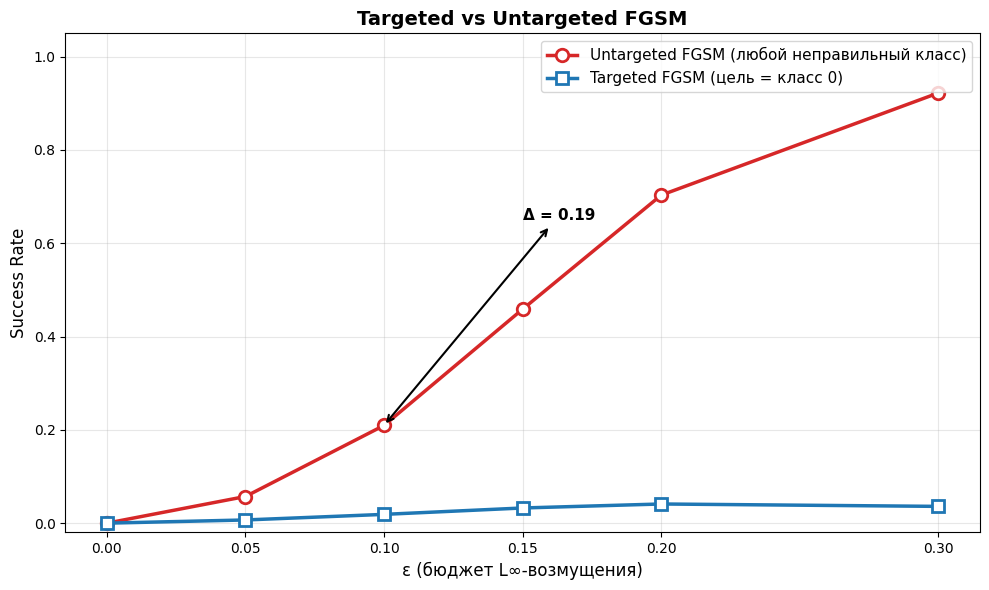

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(epsilons_test, asr_untargeted,
         marker='o', markersize=9, lw=2.5, color='#d62728',
         markerfacecolor='white', markeredgewidth=2,
         label="Untargeted FGSM (любой неправильный класс)")

plt.plot(epsilons_test, asr_targeted,
         marker='s', markersize=9, lw=2.5, color='#1f77b4',
         markerfacecolor='white', markeredgewidth=2,
         label=f"Targeted FGSM (цель = класс {TARGET_CLASS})")

plt.title("Targeted vs Untargeted FGSM",
          fontweight='bold', fontsize=14)
plt.xlabel("ε (бюджет L∞-возмущения)", fontsize=12)
plt.ylabel("Success Rate", fontsize=12)
plt.xticks(epsilons_test)
plt.ylim(-0.02, 1.05)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)

# Аннотация разрыва при ε = 0.1
i = epsilons_test.index(0.1)
plt.annotate(
    f"Δ = {asr_untargeted[i] - asr_targeted[i]:.2f}",
    xy=(0.1, asr_untargeted[i]),
    xytext=(0.15, 0.65),
    fontsize=11, fontweight='bold',
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.5)
)

plt.tight_layout()
plt.show()

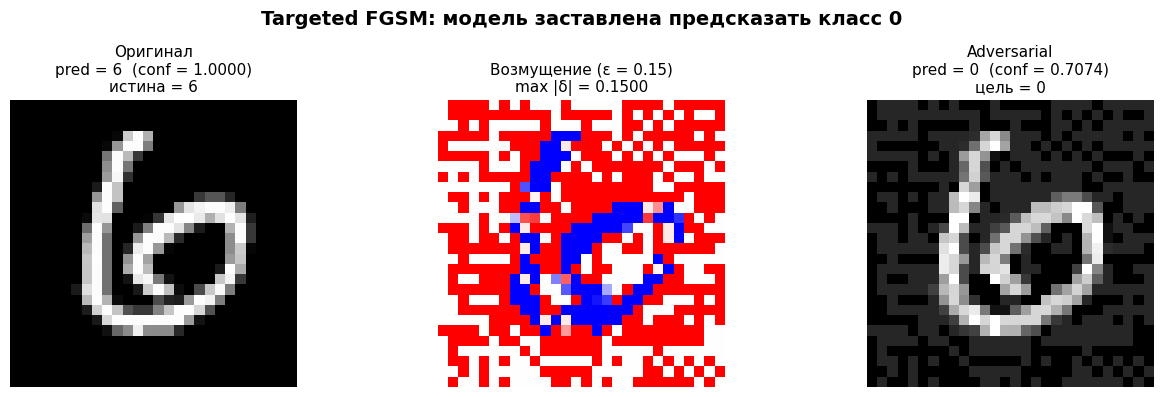

In [ ]:
def find_first_targeted_example(model, loader, epsilon, target_class, criterion):
    """
    Ищет первый пример, который targeted-атака успешно перевела в target_class.
    """
    model.eval()

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Оставляем примеры с истинным классом ≠ target
        mask = labels != target_class
        images = images[mask]
        labels = labels[mask]

        if len(images) == 0:
            continue

        y_target = torch.full_like(labels, target_class)
        x_adv = targeted_fgsm_attack(model, images, y_target, epsilon, criterion)

        with torch.no_grad():
            # Уверенность
            probs_clean = torch.softmax(model(images), dim=1)
            probs_adv = torch.softmax(model(x_adv), dim=1)
            preds_clean = probs_clean.argmax(dim=1)
            preds_adv = probs_adv.argmax(dim=1)

        # Ищем, где модель стала предсказывать target_class
        success = preds_adv == target_class
        if success.any():
            idx = success.nonzero(as_tuple=True)[0][0].item()
            return (
                images[idx].cpu(), labels[idx].cpu(), x_adv[idx].cpu(),
                preds_clean[idx].item(), preds_adv[idx].item(),
                probs_clean[idx, preds_clean[idx]].item(),
                probs_adv[idx, target_class].item(),
            )

    return None


# Запуск
result = find_first_targeted_example(model, test_loader, epsilon=0.15,
                                      target_class=0, criterion=criterion)

if result is not None:
    img, label, img_adv, pred_clean, pred_adv, conf_clean, conf_adv = result

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    # --- Оригинал ---
    axes[0].imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(
        f"Оригинал\npred = {pred_clean}  (conf = {conf_clean:.4f})\n"
        f"истина = {label.item()}",
        fontsize=11
    )
    axes[0].axis('off')

    # --- Возмущение ---
    noise = (img_adv - img).squeeze().numpy()
    axes[1].imshow(noise, cmap='bwr', vmin=-0.15, vmax=0.15)
    axes[1].set_title(f"Возмущение (ε = 0.15)\nmax |δ| = {abs(noise).max():.4f}",
                      fontsize=11)
    axes[1].axis('off')

    # --- Adversarial ---
    axes[2].imshow(img_adv.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(
        f"Adversarial\npred = {pred_adv}  (conf = {conf_adv:.4f})\n"
        f"цель = 0",
        fontsize=11
    )
    axes[2].axis('off')

    plt.suptitle("Targeted FGSM: модель заставлена предсказать класс 0",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Целевая атака мене эффективна, т.к. гораздо тяжелее ошибится и попасть точно в нужный целевой класс. При нецелевой атаке у нас 9 вариантов для ошибки против только 1 в целевой. Легче сделать любую ошибку, чем конкретнукю. Одного шага атаки не хватает для целевой - нужен точный расчет.

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: расчёт RF, реализация FGSM, график ASR(ε), сравнение с adversarial training.
